## Base model for Students Outcome Predictor

### Description:
The Baseline Model is a Logistic Regression classifier. It is chosen for its simplicity, interpretability, and speed. In this project, the model's primary goal is to distinguish between students who will `Graduate` and those who will `Dropout`.

Priority Metric: Recall for the `Dropout` class, missing a student at risk (False Negative) is much more costly than accidentally flagging a successful student (False Positive). Therefore, I will evaluate the model primarily on its ability to capture as many true `dropouts` as possible.

In [2]:
# utils folder is in the root, the notebook cannot unless the root path is added to notebook.
import sys; sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
from utils.data_utils import evaluate_classification_model, get_model_metrics

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


### 3.0 Load Data

The cleaned data was saved to `./data/processed/02.7_data_final.csv`. I will load this dataset for our modeling process.

In [3]:
df = pd.read_csv('../data/processed/02.7_data_final.csv')
df.head()

,marital_status,application_mode,application_order,course,daytime_evening,prev_qualification,prev_grade,nationality,mother_qualification,father_qualification,...,father_occupation_is_unknown,mother_occupation_is_unknown,father_qualification_is_unknown,mother_qualification_is_unknown,prev_qualification_is_unknown,any_info_missing,target_encoded,age_group,grade_progression,total_approved_units
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0,0,18-21,0.000000,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,0,0,0,0,2,18-21,-0.333333,12
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0,0,0,0,0,18-21,0.000000,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,0,0,0,0,2,18-21,-1.028571,11
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,0,0,0,0,2,31+,0.666667,11


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   marital_status                   4424 non-null   int64  
 1   application_mode                 4424 non-null   int64  
 2   application_order                4424 non-null   int64  
 3   course                           4424 non-null   int64  
 4   daytime_evening                  4424 non-null   int64  
 5   prev_qualification               4424 non-null   int64  
 6   prev_grade                       4424 non-null   float64
 7   nationality                      4424 non-null   int64  
 8   mother_qualification             4424 non-null   int64  
 9   father_qualification             4424 non-null   int64  
 10  mother_occupation                4424 non-null   int64  
 11  father_occupation                4424 non-null   int64  
 12  admission_grade     

***Interpretation:*** Imported data from the proccess data successfully, however, datatypes are not saved to the file. I will need to convert them to the appropriate types before modeling.

#### 3.1 Fix datatypes

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   marital_status                   4424 non-null   int64  
 1   application_mode                 4424 non-null   int64  
 2   application_order                4424 non-null   int64  
 3   course                           4424 non-null   int64  
 4   daytime_evening                  4424 non-null   int64  
 5   prev_qualification               4424 non-null   int64  
 6   prev_grade                       4424 non-null   float64
 7   nationality                      4424 non-null   int64  
 8   mother_qualification             4424 non-null   int64  
 9   father_qualification             4424 non-null   int64  
 10  mother_occupation                4424 non-null   int64  
 11  father_occupation                4424 non-null   int64  
 12  admission_grade     

##### 3.1.1 Fix binary columns datatypes

In [6]:
int_cols = ['displaced', 'special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'international', 'daytime_evening', 'age_at_enrollment', 'cu1_credited', 'cu1_enrolled', 'cu1_evaluations', 'cu1_approved', 'cu1_no_evaluations', 'cu2_credited', 'cu2_enrolled', 'cu2_evaluations', 'cu2_approved', 'cu2_no_evaluations', 'total_approved_units']
df[int_cols] = df[int_cols].astype('int8')

# additional engineered features
unknown_flags = [
    'father_occupation_is_unknown', 'mother_occupation_is_unknown',
    'father_qualification_is_unknown', 'mother_qualification_is_unknown',
    'prev_qualification_is_unknown', 'any_info_missing'
]
df[unknown_flags] = df[unknown_flags].astype('int8')

# target variable
df['target_encoded'] = df['target_encoded'].astype('int8')


df[int_cols].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   displaced                4424 non-null   int8 
 1   special_needs            4424 non-null   int8 
 2   debtor                   4424 non-null   int8 
 3   tuition_fees_up_to_date  4424 non-null   int8 
 4   gender                   4424 non-null   int8 
 5   scholarship_holder       4424 non-null   int8 
 6   international            4424 non-null   int8 
 7   daytime_evening          4424 non-null   int8 
 8   age_at_enrollment        4424 non-null   int8 
 9   cu1_credited             4424 non-null   int8 
 10  cu1_enrolled             4424 non-null   int8 
 11  cu1_evaluations          4424 non-null   int8 
 12  cu1_approved             4424 non-null   int8 
 13  cu1_no_evaluations       4424 non-null   int8 
 14  cu2_credited             4424 non-null   int8 
 15  cu2_

****Interpretation:**** Binary and integer columns have been converted to int8 for memory efficiency. The memory usage has been reduced to `86.5KB` from `1.6+MB`


##### 3.1.2 Fix Category columns datatypes

In [7]:
categorical_cols = [
    'marital_status',
    'application_mode',
    'application_order',
    'course',
    'prev_qualification',
    'nationality',
    'mother_qualification',
    'father_qualification',
    'mother_occupation',
    'father_occupation'
]
df[categorical_cols] = df[categorical_cols].astype('category')

# new engineered feature as category
df['age_group'] = df['age_group'].astype('category')
df.info()

df[categorical_cols].info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   marital_status                   4424 non-null   category
 1   application_mode                 4424 non-null   category
 2   application_order                4424 non-null   category
 3   course                           4424 non-null   category
 4   daytime_evening                  4424 non-null   int8    
 5   prev_qualification               4424 non-null   category
 6   prev_grade                       4424 non-null   float64 
 7   nationality                      4424 non-null   category
 8   mother_qualification             4424 non-null   category
 9   father_qualification             4424 non-null   category
 10  mother_occupation                4424 non-null   category
 11  father_occupation                4424 non-null   category
 12  admiss

***Interpretation:*** All category columns were converted to category datatype, including the new features created during feature engineering in step 2.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   marital_status                   4424 non-null   category
 1   application_mode                 4424 non-null   category
 2   application_order                4424 non-null   category
 3   course                           4424 non-null   category
 4   daytime_evening                  4424 non-null   int8    
 5   prev_qualification               4424 non-null   category
 6   prev_grade                       4424 non-null   float64 
 7   nationality                      4424 non-null   category
 8   mother_qualification             4424 non-null   category
 9   father_qualification             4424 non-null   category
 10  mother_occupation                4424 non-null   category
 11  father_occupation                4424 non-null   category
 12  admiss

*** Interpretation:*** All columns were updated to correct datatype, including the features that were created during the step feature engineerin in step 2.

### 3.2 Data Preparation: Remove Target Columns

In this step I will separate the features from the target columns. Also, I will filter out `Enrolled` students as these students will be used to deploy the model. So, the model will be trained using students with status `Graduate` or `Dropout`.

In [9]:
# create a copy excluding students with status Enrolled
df_baseline = df[df['target_encoded'] != 1].copy()

# define features and target
X = df_baseline.drop(['target', 'target_encoded'], axis=1)

# update the encoded values to mapping it to 0 and 1
# 0 = Dropout, 1 = Graduate to have a clean binary column.
y = df_baseline['target_encoded'].map({0:0, 2:1})


***Interpretation:*** Features and target were defined. Also, the target column was updated to a binary column with `0` for `Dropout` and `1` for `Graduate`.

In [10]:
X.shape, y.shape

((3630, 45), (3630,))

***Interpretation:*** The final dataset contains `3,630 rows`, `45 features`, and `1 target` variable.

### 3.3 Preprocessing and Pipeline

I will use ColumnTransformer to scale numeric features and encode categories. Then, create a pipeline for the base model.

In [11]:
# numerical features will be process with a StandardScaler
numeric_features = ['age_at_enrollment', 'cu1_grade', 'cu2_grade', 'total_approved_units', 'grade_progression']
# binary features
binary_features = ['debtor', 'tuition_fees_up_to_date', 'scholarship_holder', 'any_info_missing']
# Onehotencoder
categorical_features = ['age_group']


preprocessor = ColumnTransformer(transformers=[
    ('numerical', StandardScaler(), numeric_features),
    ('binary', 'passthrough', binary_features),
    ('categorical', OneHotEncoder(drop='first'), categorical_features)
])


# pipeline with LogisticRegression with a class_weight balance to hande the imbalance in Dropout vs Graduate
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

***Interpretation:*** A ColumnTransformer was created to encode numerical, binary, and categorical columns. The column transformer was passed to a pipeline with a LogisticRegression. The LogisticRegression was created with a params `class_weight=balanced` to handle the imbalance between `Graduate` and `Dropout`.

### 3.4 Training and Validation


In [12]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

#train model
baseline_pipeline.fit(X_train,y_train)

# evaluate prediction
y_pred = baseline_pipeline.predict(X_test)

print("Baseline Model: Logistic Regression")
print(classification_report(y_test, y_pred, target_names=['Dropout', 'Graduate']))


Baseline Model: Logistic Regression
              precision    recall  f1-score   support

     Dropout       0.86      0.82      0.84       284
    Graduate       0.89      0.91      0.90       442

    accuracy                           0.88       726
   macro avg       0.88      0.87      0.87       726
weighted avg       0.88      0.88      0.88       726



***Interpretation:*** The `accuracy` of the base model was `0.88`, this means the model correctly predict the outcome for `88%` of the students in the test set. For a baseline model, this is a good accuracy, but we can try to improve it by tuning the hyperparameters or using more advanced models.

The `precision` was `0.86` for `Dropout` students, so the model succesfully identified `86%` of students who `Dropout`. This means that there is low `False Positive` with a `14%`.

The `F1-Score` is `0.84` which confirms the model is good identifying `Dropouts`

The `recall` which is the main metric to use in this project, was `0.82`, meaning that of all students who `Dropout` the model actually identified `82%` of them. The model is missing `18%` of `Dropouts`, I will try to improve the model to avoid missing potential dropout to allow advisor to help students on time before they dropout.



### 3.5 Confusion Matrix

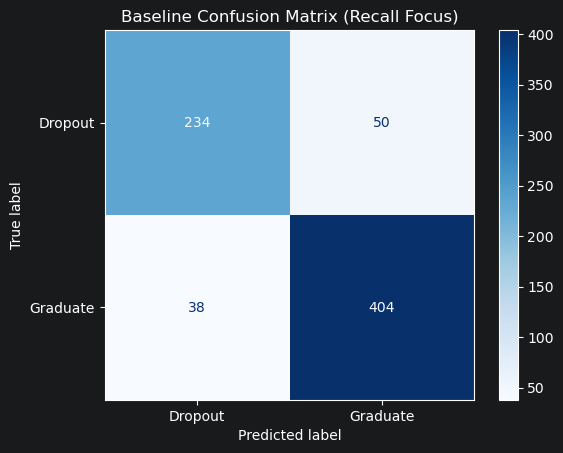

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=['Dropout', 'Graduate'],
                                        cmap='Blues')
plt.title('Baseline Confusion Matrix (Recall Focus)')
plt.show()

***Interpretation:*** The total of `True Positive` was `234`, the model correctly caught `234` dropouts.

The amount of `True Negative` was `404`, this is the amount of students who `Graduate` and the model correctly identified them.

The amount of `False Positive` was `38`, meaning the model incorrectly identified `38` students who `Graduate` as `Dropout`. In this project, this value doesn't have importance because I prefer to flag a students as at risk of `Dropout` than missing a real student who is actually at risk.

The `False Negative` is `50`, meaning the model missed `50` students who `Dropout`, reducing this number is the goal when training better models. I want to improve the model to avoid missing potential dropout to allow advisor to help students on time before they dropout.

### 3.6 Baseline Model Review

The Logistic Regression has successfully established a performance baseline for predicting student outcomes.  By focusing on binary classification (Graduate vs. Dropout) and using a balanced class weight, I will try to improve the recall `82%`.

## 4.0 Improving the baseline model

In this step I will try to improve the baseline model. First, I will include new features to the Logistic Regression model and compare the improvements. Then, I will try to improve the model by experimenting with different hyperparameters. I will use `GridSearchCV` to find the best hyperparameters for the model. The expectation is to improve the recall from `82%` which was the recall score from the baseline model.



### 4.1 Adding new features to the base model

To improve the model I will add academic performance and demographic data that showed importance during the EDA. The new features that I will use are: `cu1_approved`, `cu2_approved`, `course`, and `gender`.

Logistic Regression: With new Features: evaluation results
              precision    recall  f1-score   support

     Dropout       0.87      0.85      0.86       284
    Graduate       0.90      0.92      0.91       442

    accuracy                           0.89       726
   macro avg       0.89      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726



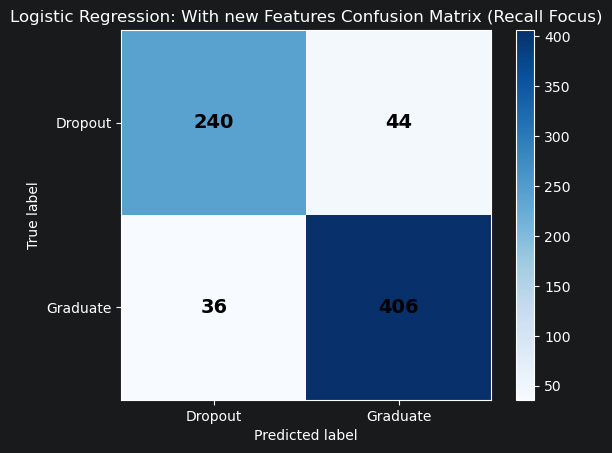

In [14]:
# numerical features will be process with a StandardScaler
numeric_features = ['age_at_enrollment', 'cu1_grade', 'cu2_grade', 'total_approved_units', 'grade_progression', 'cu1_approved', 'cu2_approved']
# binary features
binary_features = ['debtor', 'tuition_fees_up_to_date', 'scholarship_holder', 'any_info_missing', 'gender']
# One hot encoder
categorical_features = ['age_group', 'course']


preprocessor = ColumnTransformer(transformers=[
    ('numerical', StandardScaler(), numeric_features),
    ('binary', 'passthrough', binary_features),
    ('categorical', OneHotEncoder(drop='first'), categorical_features)
])


# pipeline with LogisticRegression with a class_weight balance to hande the imbalance in Dropout vs Graduate
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

lr_model.fit(X_train,y_train)

# evaluate prediction
y_pred = lr_model.predict(X_test)

evaluate_classification_model(y_test, y_pred, target_names=['Dropout', 'Graduate'],                          model_name= "Logistic Regression: With new Features")




***Interpretation:*** Adding new features that showed importance during EDA slightly improved the model. The `precision` and `accuracy` scores increased by only `1%`, the `f1` score on `Dropouts` increase from `84%` to `86%`.

The `recall` score on `Dropouts` increase from `82%` to `85%`. This is a good improvement, but the model still has room for improvement.

From the Confusion Matrix, I can see that the number of false negatives has decreased from `50` to `44`, and the amount of correctly identified as `Droptout` from `234` to `240`. This is a good sign of improvement, even when the number of false positives increased, because I prefeer misclassifying a student as risk than missing a student that is actually at risk.



### 4.2 GridSearchCV Hyperparameter Tuning

In [15]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(
    lr_model,
    param_grid,
    cv=5,
    scoring='recall',
    verbose=1
)

grid_search.fit(X_train,y_train)

# best model
best_model = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}


***Interpretation:*** The `GridSearchCV` hyperparameter tuning was performed to find the best combination of hyperparameters for the logistic regression model. I tested 5 values for `C (0.01, 0.1, 1,10,100)` and 2 types of `solver (libfgs, liblinear)` for a total of 10 combinations, with 5 fold cross-validation for a total of 50 training cycles.

The best parameter found were the following:
- `C = 0.01`, the smaller values means stronger regularization, meaning that a more constrained model perform better at identifying dropouts.
- `penalty = l2`, standard Ridge regularization, it penalized large coefficients across all features.
- `solver = liblinear`, this solver is suitable for small datasets or l2 penalties on binary classification, and is known for its efficiency.

#### 4.2.1 Evaluating the Best Logistic Regression Model

Best Logistic Regression Model: evaluation results
              precision    recall  f1-score   support

     Dropout       0.89      0.81      0.85       284
    Graduate       0.88      0.94      0.91       442

    accuracy                           0.89       726
   macro avg       0.89      0.87      0.88       726
weighted avg       0.89      0.89      0.89       726



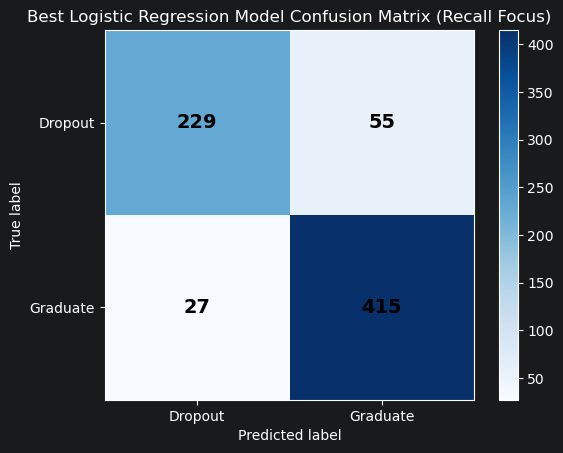

In [16]:
evaluate_classification_model(y_test, best_model.predict(X_test), model_name='Best Logistic Regression Model')

**Interpretation:** Comparing the GridSearchCV results with the model with new features, I can see the new model caught `240` Dropout for a `85%` recall while the model with new features caught `229` Dropout for a `81%` recall. The recall dropped by a `4%`, this could have happened because of the strong regularization `C=0.01`, this makes the model more conservative to prevent overfitting.

While the recall for the `GridSearchCV` model recall was less than the first model, I would still choose the `GridSearchCV` model as the better model because it was cross-validated 50 times to ensure the model performs better across different students.

Both models predict `Dropout` only if the probability is above `50%`. This means that if the model is `51%` sure a student will graduate, the model will label them as `Graduate`. In my case, classifying a student as at risk when they are not is less harmful than missing a student actually at risk. Since I want to be safe of not missing a possible dropout, I will lower the threshold to `0.4`, this means that the model needs to predict a probability of `60%` of Graduate to classifying them as `Graduate` capturing more `Dropout`.

### 4.3 Apply a custom threshold to the model

Currently, the models default probability threshold is `0.5`. I will lower the threshold to `0.4` to capture more `Dropout` students.

Logistic Regression with Custom Threshold: evaluation results
              precision    recall  f1-score   support

     Dropout       0.81      0.86      0.83       284
    Graduate       0.91      0.87      0.89       442

    accuracy                           0.87       726
   macro avg       0.86      0.86      0.86       726
weighted avg       0.87      0.87      0.87       726



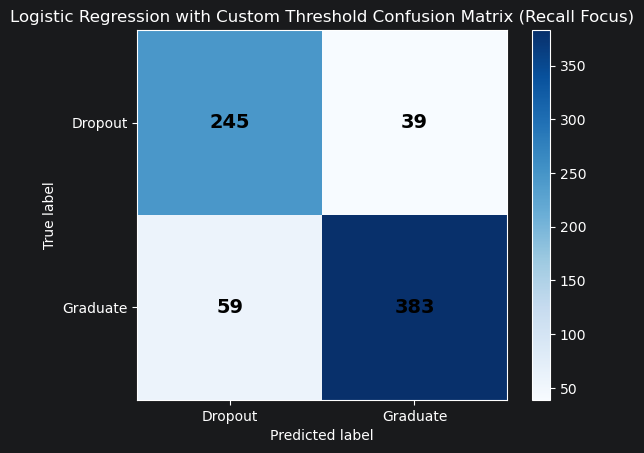

In [17]:
# 0 is Dropout, 1 is Graduate. probs = probability of being Graduate
probs = best_model.predict_proba(X_test)[:, 0]

# Set a lower threshold for Dropout to catch MORE. A student needs a 60% chance of graduating to be labeled 'Graduate'
# If they have a 55% chance of graduating, they will now be flagged as 'Dropout'
custom_threshold = 0.4
y_pred_custom = (probs <= custom_threshold).astype(int)

evaluate_classification_model(y_test, y_pred_custom, model_name='Logistic Regression with Custom Threshold')

***Interpretation:*** After updating the threshold to `0.4` the model needs to be more than `40%` sure to say the student will `Graduate` instead of the default `0.5`. By using `0.4` threshold, the recall for dropouts increase from `81%` to `86%`. The model is better with the new threshold as it captures more `Dropouts`.

From the Confusion Matrix above, I can confirm there are `39` Dropouts that the models is not capturing.

In [18]:
results_models_metrics = []

results_models_metrics.append(get_model_metrics(y_test, y_pred_custom, 'Logistic Regression'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results

hello


,Accuracy,Precision (Dropout),Recall (Dropout),F1-Score (Dropout),Precision (Graduate),Recall (Graduate),F1-Score (Graduate)
Model,,,,,,,
Logistic Regression,0.865,0.8059,0.8627,0.8333,0.9076,0.8665,0.8866


In [19]:
results_models_metrics

[{'Model': 'Logistic Regression',
  'Accuracy': 0.865,
  'Precision (Dropout)': 0.8059,
  'Recall (Dropout)': 0.8627,
  'F1-Score (Dropout)': 0.8333,
  'Precision (Graduate)': 0.9076,
  'Recall (Graduate)': 0.8665,
  'F1-Score (Graduate)': 0.8866}]